In [1]:
# parameters
group = None  # This will get overwritten by papermill

In [2]:
# Parameters
group = "LymphoidCells"


In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import scipy

import os

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import kktk

import warnings
warnings.simplefilter("ignore", UserWarning)

/rfs/project/rfs-iCNyzSAaucw/kk837/github/kktk/kktk/plotting.py:21: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [4]:
import session_info
session_info.show()

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)


In [5]:
sc.settings.set_figure_params(dpi=120)

# Variables

In [6]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets'
adata_path = f'{data_object_dir}/scVI/latent_variables/b2c_cells_{group}_correcting-donor_n-layers-3.h5ad'

In [7]:
!ls {data_object_dir}

b2c_cells_AtrialCardiomyocytes_raw.h5ad
b2c_cells_EndothelialCells_raw.h5ad
b2c_cells_EpicardialCells_raw.h5ad
b2c_cells_LymphoidCells_raw.h5ad
b2c_cells_MesenchymalCells_raw.h5ad
b2c_cells_MyeloidCells_raw.h5ad
b2c_cells_NeuralCells_raw.h5ad
b2c_cells_VentricularCardiomyocytes_raw.h5ad
scVI


# Read in adata

In [8]:
%%time
adata = sc.read_h5ad(adata_path)
adata

CPU times: user 111 ms, sys: 31.5 ms, total: 142 ms
Wall time: 1.17 s


AnnData object with n_obs × n_vars = 2289 × 50

# UMAP and Clustering

In [9]:
%%time
sc.pp.neighbors(adata, use_rep='X', n_neighbors=15)
sc.tl.umap(adata, min_dist=0.2, spread=1.0)

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CPU times: user 9.6 s, sys: 68.7 ms, total: 9.67 s
Wall time: 17.7 s


In [10]:
%%time
leiden_keys=[]
for res in tqdm([0.2,0.3,0.4,0.5,0.8,1.0,1.5,2.0,3.0,4.0]):
    leiden_key = f"leiden_{res}"
    key_added=f"scVI_{leiden_key}"
    sc.tl.leiden(adata,resolution=res,key_added=key_added,n_iterations=2)
    leiden_keys.append(key_added)

  0%|          | 0/10 [00:00<?, ?it/s]

<timed exec>:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


 10%|█         | 1/10 [00:00<00:02,  4.30it/s]

 20%|██        | 2/10 [00:00<00:01,  4.54it/s]

 30%|███       | 3/10 [00:00<00:01,  4.63it/s]

...

 80%|████████  | 8/10 [00:01<00:00,  4.81it/s]

 90%|█████████ | 9/10 [00:01<00:00,  4.84it/s]

100%|██████████| 10/10 [00:02<00:00,  4.87it/s]

100%|██████████| 10/10 [00:02<00:00,  4.77it/s]

CPU times: user 2.08 s, sys: 3.7 ms, total: 2.08 s
Wall time: 2.1 s


# Save

In [11]:
adata.write(adata_path)
adata

AnnData object with n_obs × n_vars = 2289 × 50
    obs: 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0'
    uns: 'neighbors', 'umap', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

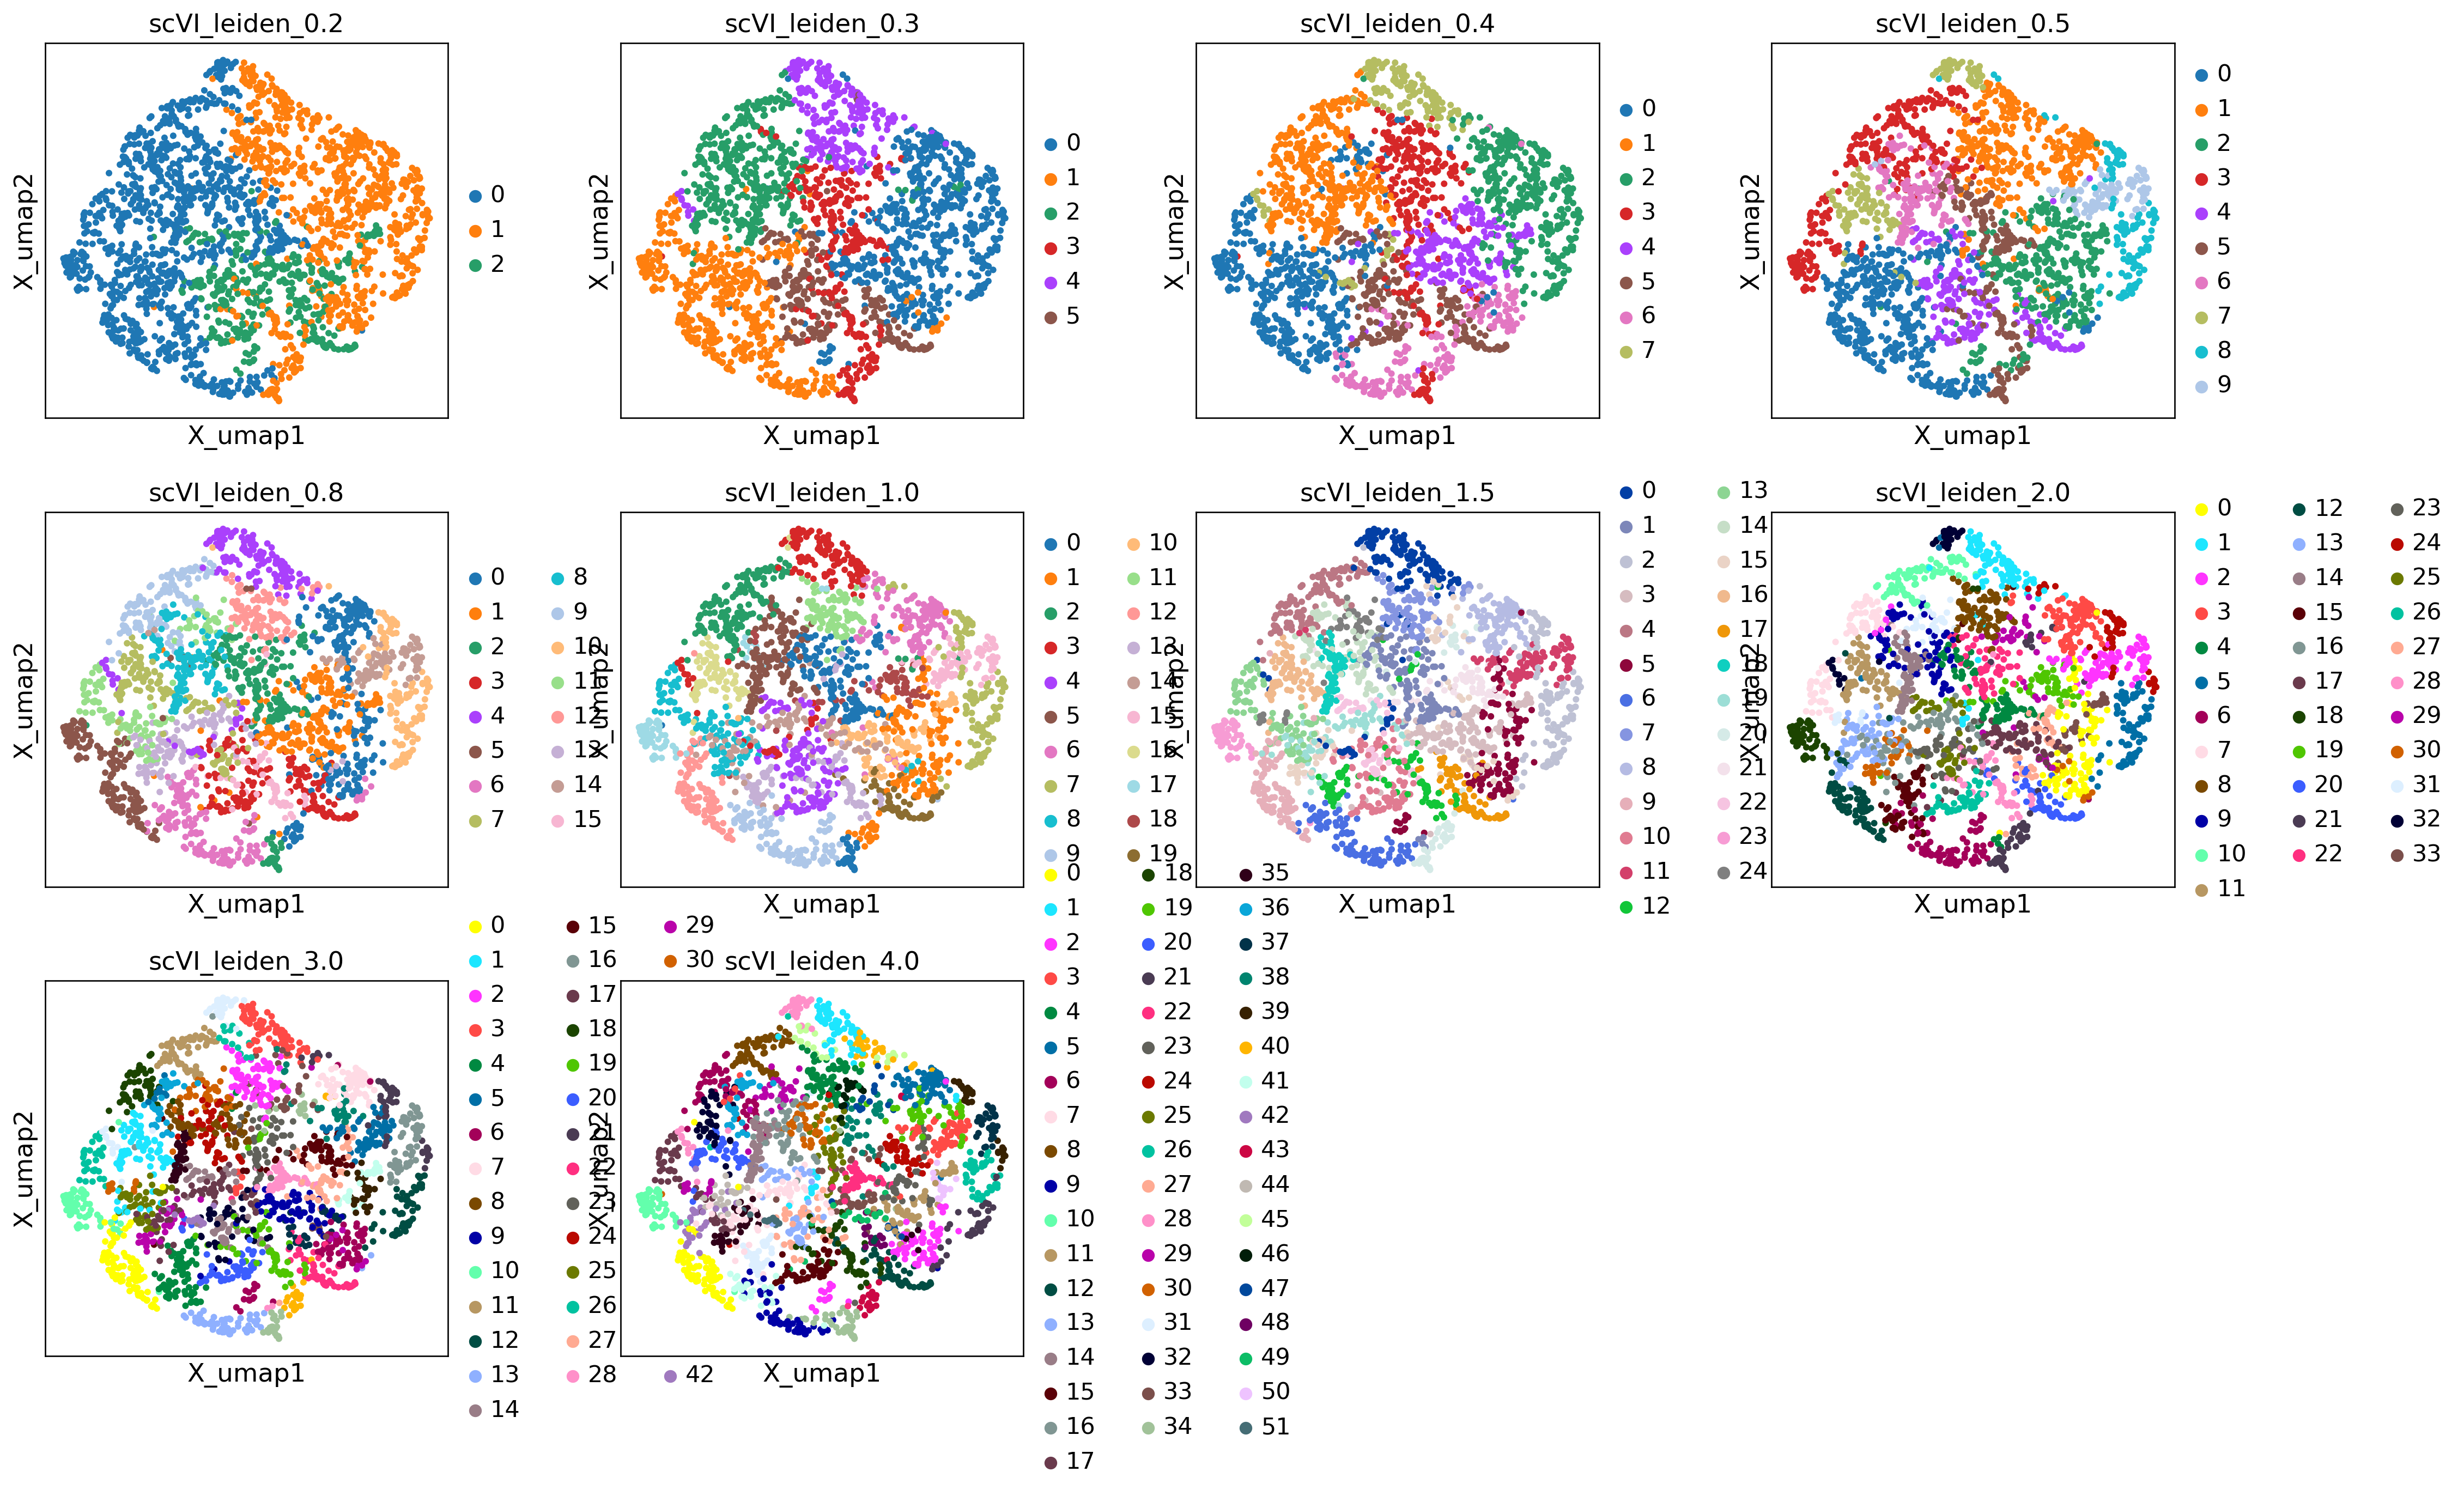

In [12]:
# plot
sc.pl.embedding(adata, basis='X_umap',
                color=leiden_keys, wspace=0.3,ncols=4)